Importações e Configuração

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import warnings
%matplotlib inline
sns.set_theme(style="whitegrid")
from IPython.utils import io

Carga e Divisão dos Dados

In [2]:
# Carregando os dados
df = pd.read_csv('../data/water_potability.csv')

# Separando Features e Target
X = df.drop('Potability', axis=1)
y = df['Potability']

# Divisão Treino e Teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Treino: {X_train.shape}")
print(f"Teste: {X_test.shape}")

Treino: (2620, 9)
Teste: (656, 9)


Pipeline de Pré-processamento

In [3]:
# Criando o pipeline de transformação
preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Mediana é mais robusta a outliers
    ('scaler', StandardScaler())
])

Comparação de Modelos (Spot-Checking)

In [5]:
warnings.filterwarnings("ignore", category=UserWarning, message="X does not have valid feature names, but LGBMClassifier was fitted with feature names")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = "roc_auc"
n_pos = np.sum(y_train == 1)
n_neg = np.sum(y_train == 0)
scale_pos_weight = n_neg / max(n_pos, 1)
xgb = XGBClassifier(eval_metric="logloss", random_state=42, scale_pos_weight=scale_pos_weight)
xgb_param_dist = {
    "learning_rate": [0.01, 0.02, 0.05, 0.1],
    "n_estimators": [200, 500, 1000],
    "max_depth": [3, 4, 6, 8],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.6, 0.7, 0.8, 0.9],
    "colsample_bytree": [0.4, 0.6, 0.8, 1.0],
    "gamma": [0, 0.1, 0.2, 0.5],
    "reg_alpha": [0, 0.1, 0.5, 1],
    "reg_lambda": [0.5, 1, 3]
}
lgb = LGBMClassifier(random_state=42, scale_pos_weight=scale_pos_weight, verbosity=-1)
lgb_param_dist = {
    "learning_rate": [0.01, 0.02, 0.05, 0.1],
    "n_estimators": [200, 500, 1000],
    "num_leaves": [15, 31, 63],
    "max_depth": [-1, 3, 5, 8],
    "min_data_in_leaf": [10, 20, 40],
    "feature_fraction": [0.6, 0.7, 0.8, 1.0],
    "bagging_fraction": [0.6, 0.7, 0.8, 1.0],
    "bagging_freq": [0, 1, 5],
    "lambda_l1": [0, 0.1, 0.5],
    "lambda_l2": [0, 0.1, 0.5, 1.0]
}

models = [
    ('Logistic Regression', LogisticRegression()),
    ('SVC', SVC(probability=True)),
    ('Random Forest', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('XGBoost', RandomizedSearchCV(xgb, xgb_param_dist, n_iter=40, scoring=scoring,
                            cv=cv, verbose=0, n_jobs=-1, random_state=42)),
    ('LightGBM', RandomizedSearchCV(lgb, lgb_param_dist, n_iter=40, scoring=scoring,
                            cv=cv, verbose=0, n_jobs=-1, random_state=42))
     ]
results = []

for name, model in models:
    # Criando um pipeline completo para cada modelo
    clf = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    with io.capture_output() as captured:
     cv_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='f1', verbose=False)
    results.append((name, cv_scores.mean()))
rs_lgb = models[4][1].fit(X_train, y_train)   # ('LightGBM', RandomizedSearchCV(...))
print("Melhores parâmetros:", rs_lgb.best_params_)
print("Melhor score:", rs_lgb.best_score_)
# Visualizando a comparação
comparison_df = pd.DataFrame(results, columns=['Model', 'F1-Score Mean']).sort_values(by='F1-Score Mean', ascending=False)
print(comparison_df)

Melhores parâmetros: {'num_leaves': 63, 'n_estimators': 1000, 'min_data_in_leaf': 40, 'max_depth': 8, 'learning_rate': 0.01, 'lambda_l2': 1.0, 'lambda_l1': 0.5, 'feature_fraction': 1.0, 'bagging_freq': 1, 'bagging_fraction': 0.7}
Melhor score: 0.6826255947080261
                 Model  F1-Score Mean
4             LightGBM       0.533438
3              XGBoost       0.520687
2        Random Forest       0.445469
1                  SVC       0.431413
0  Logistic Regression       0.001951


Treinamento e Avaliação do Modelo Final (LightGBM)

In [17]:
# Pipeline final com o melhor modelo
best_params = rs_lgb.best_params_
final_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(**best_params, random_state=42, scale_pos_weight=scale_pos_weight))
])
with io.capture_output() as captured:
 final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

# Relatório de Classificação
print("--- Relatório de Performance ---")
print(classification_report(y_test, y_pred))

--- Relatório de Performance ---
              precision    recall  f1-score   support

           0       0.69      0.72      0.71       400
           1       0.53      0.49      0.51       256

    accuracy                           0.63       656
   macro avg       0.61      0.61      0.61       656
weighted avg       0.63      0.63      0.63       656



/home/codespace/.cache/pypoetry/virtualenvs/water-potability-ml-CzojRPSR-py3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Matriz de Confusão e Importância das Variáveis

/home/codespace/.cache/pypoetry/virtualenvs/water-potability-ml-CzojRPSR-py3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


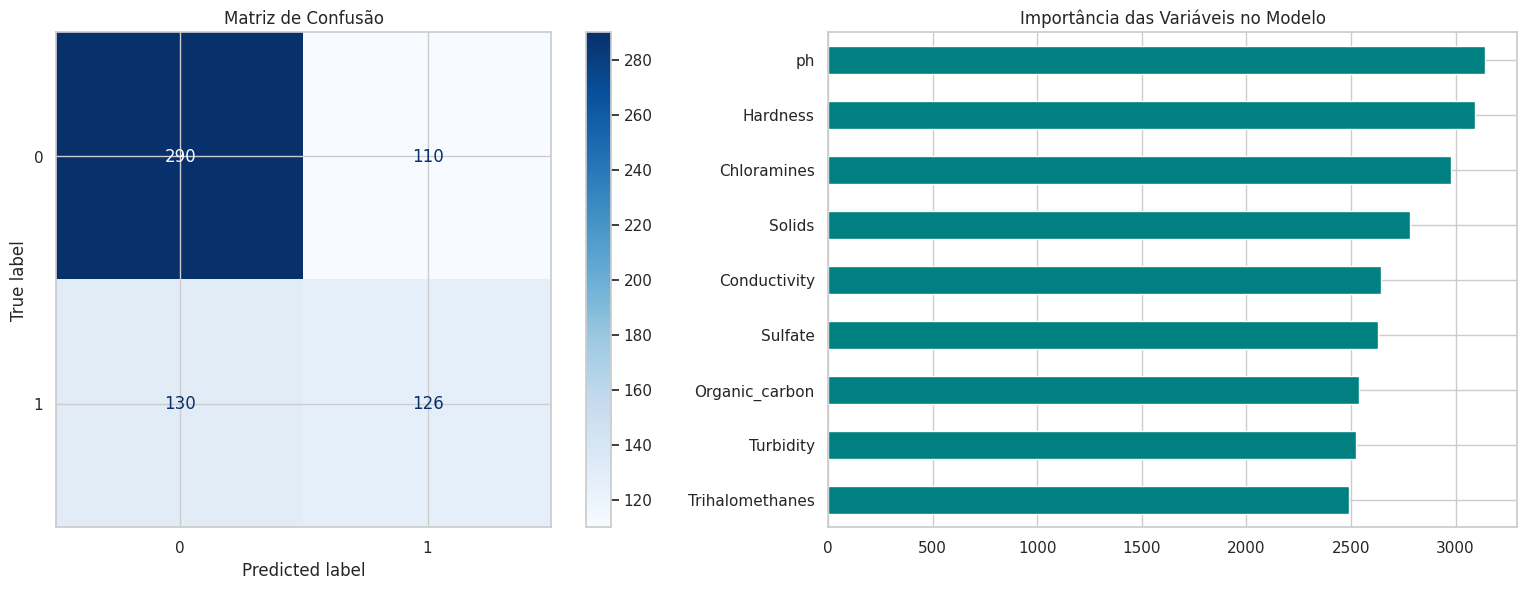

In [18]:
# Plotando a Matriz de Confusão
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test, cmap='Blues', ax=ax[0])
ax[0].set_title('Matriz de Confusão')

# Importância das Features
importances = final_model.named_steps['classifier'].feature_importances_
feature_names = X.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)
feat_imp.plot(kind='barh', ax=ax[1], color='teal')
ax[1].set_title('Importância das Variáveis no Modelo')

plt.tight_layout()
plt.show()